In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance

# Set deterministic random seed for strict reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
print("Cell 1 executed: Environment configured successfully.")

Cell 1 executed: Environment configured successfully.


In [8]:
def generate_subscription_churn_data(n_samples=12000, random_state=SEED):
    rng = np.random.RandomState(random_state)
    
    tenure_months = rng.exponential(scale=14, size=n_samples).clip(1, 72)
    monthly_charges = rng.normal(loc=70, scale=25, size=n_samples).clip(20, 150)
    total_logins_l30d = rng.poisson(lam=18, size=n_samples)
    support_tickets_l90d = rng.poisson(lam=2.5, size=n_samples)
    contract_type = rng.choice(['Month-to-Month', 'One-Year', 'Two-Year'], p=[0.55, 0.25, 0.20], size=n_samples)
    payment_method = rng.choice(['Credit Card', 'Bank Transfer', 'Electronic Check'], p=[0.4, 0.3, 0.3], size=n_samples)
    
    # Latent churn log-odds with interaction and non-linear decay
    logit = (
        -1.2
        - 0.08 * tenure_months
        + 0.015 * monthly_charges
        - 0.12 * total_logins_l30d
        + 0.45 * support_tickets_l90d
        + 1.1 * (contract_type == 'Month-to-Month')
        - 0.9 * (contract_type == 'Two-Year')
        + 0.35 * (payment_method == 'Electronic Check')
        + 0.02 * (monthly_charges * support_tickets_l90d) # Interaction
        + rng.normal(0, 0.4, size=n_samples)
    )
    
    prob_churn = 1 / (1 + np.exp(-logit))
    churn = rng.binomial(1, prob_churn)
    
    df = pd.DataFrame({
        'tenure_months': tenure_months,
        'monthly_charges': monthly_charges,
        'total_logins_l30d': total_logins_l30d,
        'support_tickets_l90d': support_tickets_l90d,
        'contract_type': contract_type,
        'payment_method': payment_method,
        'churn': churn
    })
    return df

df = generate_subscription_churn_data(n_samples=12000)
print(f"Dataset Shape: {df.shape}")
print(f"Overall Churn Base Rate: {df['churn'].mean():.2%}")
df.head()

Dataset Shape: (12000, 7)
Overall Churn Base Rate: 64.02%


,tenure_months,monthly_charges,total_logins_l30d,support_tickets_l90d,contract_type,payment_method,churn
0,6.569753,54.355674,14,4,One-Year,Bank Transfer,1
1,42.141700,75.748109,20,4,Month-to-Month,Credit Card,1
2,18.434440,89.444941,8,3,Month-to-Month,Electronic Check,1
3,12.781196,51.692511,16,4,Two-Year,Credit Card,1
4,2.374748,89.533953,10,2,One-Year,Electronic Check,0


In [9]:
X = df.drop(columns=['churn'])
y = df['churn']

# Stratified split to preserve class ratios between train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

numeric_features = ['tenure_months', 'monthly_charges', 'total_logins_l30d', 'support_tickets_l90d']
categorical_features = ['contract_type', 'payment_method']

# Pipeline that only fits on training data to prevent data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

print(f"Training set: {X_train.shape[0]} records | Test holdout: {X_test.shape[0]} records")

Training set: 9600 records | Test holdout: 2400 records


In [10]:
# Compute scale factor for cost-sensitive balancing
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    "Logistic Regression (L2)": LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    "LightGBM (Cost-Sensitive)": LGBMClassifier(scale_pos_weight=scale_pos,
                                               n_estimators=200, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbose=-1)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    cv_pr_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    
    pipe.fit(X_train, y_train)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]
    
    test_auc = roc_auc_score(y_test, y_pred_proba)
    test_pr_auc = average_precision_score(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)
    
    results.append({
        "Model": name,
        "CV ROC-AUC": round(cv_auc, 3),
        "Test ROC-AUC": round(test_auc, 3),
        "Test PR-AUC": round(test_pr_auc, 3),
        "Brier Score": round(brier, 3)
    })

results_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)
display(results_df)

,Model,CV ROC-AUC,Test ROC-AUC,Test PR-AUC,Brier Score
0,Logistic Regression (L2),0.914,0.917,0.952,0.115
2,LightGBM (Cost-Sensitive),0.911,0.916,0.952,0.116
1,Random Forest,0.900,0.903,0.941,0.120


Optimal Decision Threshold: 0.077
Max Portfolio Financial Utility on Test Set: $276,360.00


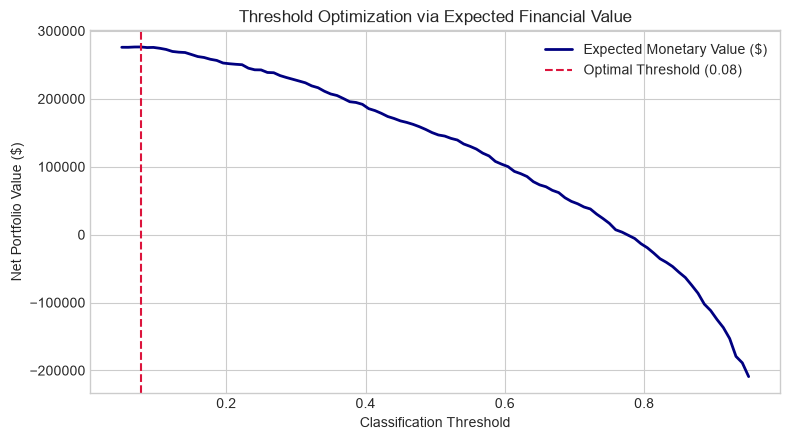

In [11]:
# Economic Assumptions:
# CLV saved if customer retained: $400
# Retention Campaign Cost: $40
# Intervention Success Rate: 60%
# True Positive Benefit = 0.60 * ($400 - $40) - 0.40 * ($40) = $200
# False Positive Cost = -$40
# False Negative Cost = -$400
# True Negative = $0

best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', models["LightGBM (Cost-Sensitive)"])
])
best_model.fit(X_train, y_train)
y_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 100)
expected_values = []

for thresh in thresholds:
    preds = (y_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    # Financial utility function calculation
    total_val = (tp * 200) + (fp * -40) + (fn * -400) + (tn * 0)
    expected_values.append(total_val)

optimal_idx = np.argmax(expected_values)
optimal_threshold = thresholds[optimal_idx]
max_financial_utility = expected_values[optimal_idx]

print(f"Optimal Decision Threshold: {optimal_threshold:.3f}")
print(f"Max Portfolio Financial Utility on Test Set: ${max_financial_utility:,.2f}")

# Plotting the financial decision curve
plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, expected_values, color='navy', lw=2, label='Expected Monetary Value ($)')
plt.axvline(optimal_threshold, color='crimson', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title('Threshold Optimization via Expected Financial Value')
plt.xlabel('Classification Threshold')
plt.ylabel('Net Portfolio Value ($)')
plt.legend()
plt.tight_layout()
plt.show()

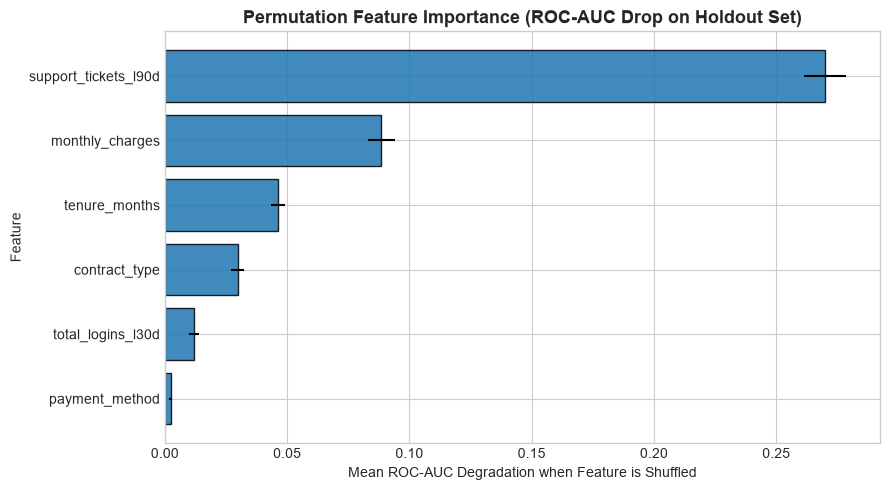

--- Feature Importance Ranking ---


,Feature,Mean ROC-AUC Drop,Std Dev
0,support_tickets_l90d,0.2700,0.0085
1,monthly_charges,0.0886,0.0055
2,tenure_months,0.0463,0.0029
3,contract_type,0.0299,0.0026
4,total_logins_l30d,0.0120,0.0020
5,payment_method,0.0023,0.0007


In [12]:
# Permutation feature importance on the holdout test set (no C/LLVM dependencies)
perm_results = permutation_importance(
    best_model, 
    X_test, 
    y_test, 
    scoring='roc_auc', 
    n_repeats=10, 
    random_state=SEED, 
    n_jobs=-1
)

sorted_importances_idx = perm_results.importances_mean.argsort()
sorted_features = X_test.columns[sorted_importances_idx]
sorted_means = perm_results.importances_mean[sorted_importances_idx]
sorted_stds = perm_results.importances_std[sorted_importances_idx]

# Plot Global Feature Importance Bar Chart
plt.figure(figsize=(9, 5))
plt.barh(sorted_features, sorted_means, xerr=sorted_stds, color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title("Permutation Feature Importance (ROC-AUC Drop on Holdout Set)", fontsize=13, weight='bold')
plt.xlabel("Mean ROC-AUC Degradation when Feature is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Display summary ranking table
importance_df = pd.DataFrame({
    'Feature': sorted_features[::-1],
    'Mean ROC-AUC Drop': sorted_means[::-1].round(4),
    'Std Dev': sorted_stds[::-1].round(4)
})
print("--- Feature Importance Ranking ---")
display(importance_df)